# Import Libraries

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# XOR Dataset

In [19]:
# 1. XOR Dataset
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])


# Activation Functions

In [20]:
# 2. Activation Functions

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Binary Cross-Entropy Loss

In [21]:
# 3. Binary Cross Entropy Loss

def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Initialize Parameters

In [31]:
# 4. Initialize Parameters

np.random.seed(42)

input_neurons = 2
hidden_neurons = 4
output_neurons = 1

W1 = np.random.randn(input_neurons, hidden_neurons)
b1 = np.zeros((1, hidden_neurons))

W2 = np.random.randn(hidden_neurons, output_neurons)
b2 = np.zeros((1, output_neurons))

learning_rate = 0.01
epochs = 10000

losses = []
accuracies = []

# Forward + Backpropagation

In [32]:
# 5. Training Loop

for epoch in range(epochs):

    # ----- Forward Pass -----
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    # ----- Loss -----
    loss = binary_cross_entropy(y, A2)
    losses.append(loss)

    # ----- Backpropagation -----
    dZ2 = A2 - y
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # ----- Update -----
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    # ----- Accuracy -----
    predictions = (A2 > 0.5).astype(int)
    acc = accuracy_score(y, predictions)
    accuracies.append(acc)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch} Loss: {loss:.6f}")


Epoch 0 Loss: 0.917893
Epoch 1000 Loss: 0.470017
Epoch 2000 Loss: 0.114425
Epoch 3000 Loss: 0.046131
Epoch 4000 Loss: 0.026693
Epoch 5000 Loss: 0.018248
Epoch 6000 Loss: 0.013674
Epoch 7000 Loss: 0.010853
Epoch 8000 Loss: 0.008952
Epoch 9000 Loss: 0.007592


# Final Predictions

In [34]:
# 6. Predictions

# Forward pass again using final weights
Z1 = np.dot(X, W1) + b1
A1 = relu(Z1)
Z2 = np.dot(A1, W2) + b2
A2 = sigmoid(Z2)

pred_probs = A2
pred_classes = (pred_probs > 0.5).astype(int)

print("\nFinal Predictions:")
for i in range(len(X)):
    print(f"Input: {X[i]}  Predicted: {pred_probs[i][0]:.4f}  Rounded: {pred_classes[i][0]}")
# 6. Final Evaluation

final_predictions = (A2 > 0.5).astype(int)


Final Predictions:
Input: [0 0]  Predicted: 0.0172  Rounded: 0
Input: [0 1]  Predicted: 0.9967  Rounded: 1
Input: [1 0]  Predicted: 0.9967  Rounded: 1
Input: [1 1]  Predicted: 0.0023  Rounded: 0


# Evaluation Metrics

In [35]:
accuracy = accuracy_score(y, final_predictions)
precision = precision_score(y, final_predictions)
recall = recall_score(y, final_predictions)
f1 = f1_score(y, final_predictions)
cm = confusion_matrix(y, final_predictions)

print("\nFinal Evaluation Metrics")
print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1 Score  :", f1)
print("\nConfusion Matrix:\n", cm)


Final Evaluation Metrics
Accuracy  : 1.0
Precision : 1.0
Recall    : 1.0
F1 Score  : 1.0

Confusion Matrix:
 [[2 0]
 [0 2]]


# Plot Training Curves

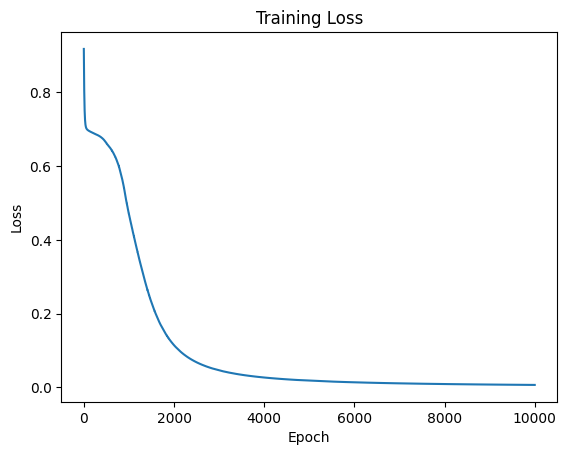

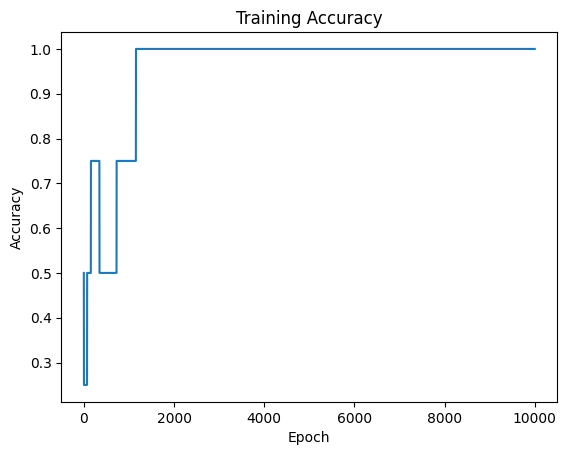

In [36]:
# 7. Plot Loss Curve
plt.figure()
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 8. Plot Accuracy Curve
plt.figure()
plt.plot(accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Decision Boundary

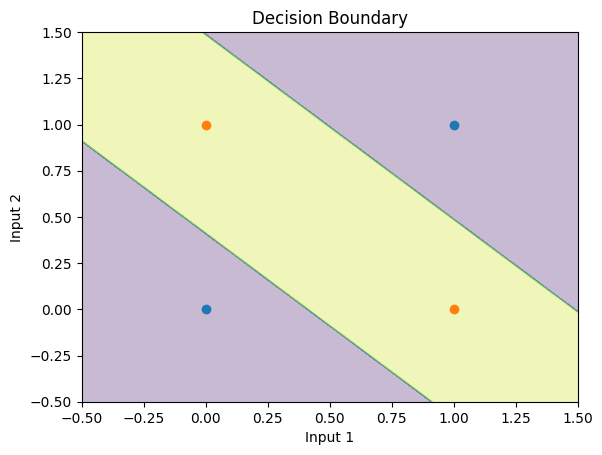

In [38]:
# 9. Decision Boundary

x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]

Z1_grid = np.dot(grid, W1) + b1
A1_grid = relu(Z1_grid)
Z2_grid = np.dot(A1_grid, W2) + b2
A2_grid = sigmoid(Z2_grid)

Z = (A2_grid > 0.5).astype(int)
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[y.flatten()==0][:,0], X[y.flatten()==0][:,1])
plt.scatter(X[y.flatten()==1][:,0], X[y.flatten()==1][:,1])
plt.title("Decision Boundary")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.show()